# Generation Score Progress

This notebook reads a GA generation history JSON file and plots the `best_score` for each generation.

<Figure size 800x450 with 0 Axes>

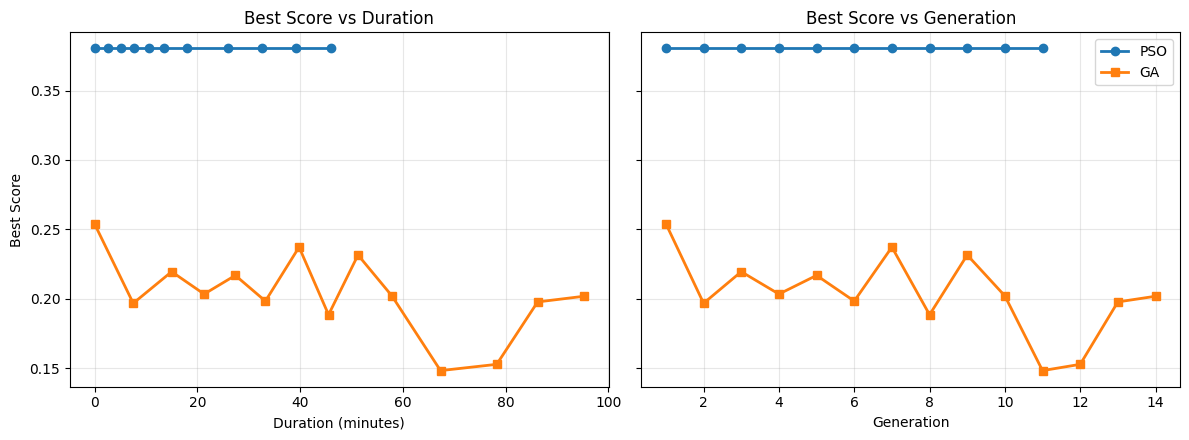

In [4]:
import json
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt

# Set this to the JSON file produced during GA training.
# Example: Path("ga_generation_history.json")
json_path_pso = Path("pso_history/pso_generation_history_1776322801.json")
json_path_ga = Path("ga_history/ga_generation_history_1776279115.json")

with json_path_pso.open("r", encoding="utf-8") as f:
    history_pso = json.load(f)

with json_path_ga.open("r", encoding="utf-8") as f:
    history_ga = json.load(f)

if not history_pso and not history_ga:
    raise ValueError(f"No data found in {json_path_pso} or {json_path_ga}")

generations_pso = [entry["generation"] for entry in history_pso]
best_scores_pso = [entry["best_score"] for entry in history_pso]

generations_ga = [entry["generation"] for entry in history_ga]
best_scores_ga = [entry["best_score"] for entry in history_ga]

plt.figure(figsize=(8, 4.5))

def parse_iso8601_utc(ts: str) -> datetime:
    ts = ts.replace("Z", "+00:00")
    if ts.endswith("+00:00"):
        base = ts[:-6]
        tz = "+00:00"
    else:
        base = ts
        tz = ""

    if "." in base:
        date_part, frac = base.split(".", 1)
        frac = (frac + "000000")[:6]  # datetime.fromisoformat supports max microseconds
        base = f"{date_part}.{frac}"

    return datetime.fromisoformat(base + tz)

# Convert timestamps to durations in minutes
start_time_pso = parse_iso8601_utc(history_pso[0]["timestamp"])
durations_pso = [(parse_iso8601_utc(entry["timestamp"]) - start_time_pso).total_seconds() / 60 for entry in history_pso]

start_time_ga = parse_iso8601_utc(history_ga[0]["timestamp"])
durations_ga = [(parse_iso8601_utc(entry["timestamp"]) - start_time_ga).total_seconds() / 60 for entry in history_ga]

# Replace the single-plot setup with two subplots:
plt.clf()
fig, (ax_duration, ax_generation) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# Plot 1: Best score vs elapsed time (minutes) — keep existing plot
ax_duration.plot(durations_pso, best_scores_pso, marker="o", linewidth=2, label="PSO")
ax_duration.plot(durations_ga, best_scores_ga, marker="s", linewidth=2, label="GA")
ax_duration.set_title("Best Score vs Duration")
ax_duration.set_xlabel("Duration (minutes)")
ax_duration.set_ylabel("Best Score")
ax_duration.grid(True, alpha=0.3)

# Plot 2: Best score vs generation number
ax_generation.plot(generations_pso, best_scores_pso, marker="o", linewidth=2, label="PSO")
ax_generation.plot(generations_ga, best_scores_ga, marker="s", linewidth=2, label="GA")
ax_generation.set_title("Best Score vs Generation")
ax_generation.set_xlabel("Generation")
ax_generation.grid(True, alpha=0.3)

plt.tight_layout()

# Plot legend
plt.legend()

plt.show()